# Flood Prediction in Metro Manila: EDA and Baseline Models

Exploratory analysis of the Metro Manila daily flood dataset (2016-2020, from Kaggle) and a first comparison of classifiers using default settings.

**Scope of this notebook:** default hyperparameters, no oversampling, and a plain random train/test split. The final evaluation (SMOTE, GridSearchCV, precision / recall / F1 / ROC-AUC) is in `02_smote_tuning_and_evaluation.ipynb`.

**Data:** download the CSV from Kaggle and save it as `data/flood_prediction.csv` (see `data/README.md`).

## Setup

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load data and basic checks

In [2]:
Flood = pd.read_csv('../data/flood_prediction.csv')

In [3]:
Flood.shape

(7308, 7)

In [4]:
Flood.describe()

,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
count,7308.000000,7308.000000,7308.000000,7308.000000,7308.000000
mean,10.052874,1.266379,15.184989,17.000000,0.018062
std,7.101769,0.902239,5.994044,15.557414,0.133186
min,0.100000,0.500000,5.000000,5.000000,0.000000
25%,4.900000,0.500000,10.900000,5.000000,0.000000
50%,8.400000,1.000000,14.900000,10.000000,0.000000
75%,13.500000,1.800000,19.100000,22.000000,0.000000
max,52.700000,6.400000,39.700000,43.000000,1.000000


In [5]:
Flood.columns

Index(['Date', 'Location', 'Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct',
       'Elevation_m', 'FloodOccurrence'],
      dtype='object')

In [6]:
Flood.head()

,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
0,2016-01-01,Quezon City,12.0,0.5,15.3,43,0
1,2016-01-01,Marikina,10.6,1.8,23.2,15,0
2,2016-01-01,Manila,5.7,0.5,15.6,5,0
3,2016-01-01,Pasig,3.7,0.5,5.0,5,0
4,2016-01-02,Quezon City,3.4,0.5,13.3,43,0


In [7]:
Flood["Location"].unique()

array(['Quezon City', 'Marikina', 'Manila', 'Pasig'], dtype=object)

In [8]:
Flood.isna().sum()

Date                0
Location            0
Rainfall_mm         0
WaterLevel_m        0
SoilMoisture_pct    0
Elevation_m         0
FloodOccurrence     0
dtype: int64

In [9]:
Flood.dtypes

Date                 object
Location             object
Rainfall_mm         float64
WaterLevel_m        float64
SoilMoisture_pct    float64
Elevation_m           int64
FloodOccurrence       int64
dtype: object

In [10]:
Flood.duplicated().sum()

np.int64(0)

Convert `Date` to a datetime type.

In [12]:
Flood["Date"] = pd.to_datetime(Flood["Date"])

In [13]:
print(Flood.dtypes)

Date                datetime64[ns]
Location                    object
Rainfall_mm                float64
WaterLevel_m               float64
SoilMoisture_pct           float64
Elevation_m                  int64
FloodOccurrence              int64
dtype: object


### Target balance

Only about 1.8% of records are flood days, so the classes are heavily imbalanced.

In [14]:
Flood['FloodOccurrence'].value_counts()

FloodOccurrence
0    7176
1     132
Name: count, dtype: int64

## 1. Numeric columns and summary statistics

In [15]:
numeric_cols = Flood.select_dtypes(include=["float64", "int64"]).columns
print("Numeric columns:", numeric_cols)

Numeric columns: Index(['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m',
       'FloodOccurrence'],
      dtype='object')


In [16]:
print("\nSummary statistics of numeric features:")
numeric_cols = Flood.select_dtypes(include=["float64", "int64"]).columns.tolist()
display(Flood[numeric_cols].describe().T)

print("\nMissing values per column:")
display(Flood.isna().sum())


Summary statistics of numeric features:


,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,7308.0,10.052874,7.101769,0.1,4.9,8.4,13.5,52.7
WaterLevel_m,7308.0,1.266379,0.902239,0.5,0.5,1.0,1.8,6.4
SoilMoisture_pct,7308.0,15.184989,5.994044,5.0,10.9,14.9,19.1,39.7
Elevation_m,7308.0,17.000000,15.557414,5.0,5.0,10.0,22.0,43.0
FloodOccurrence,7308.0,0.018062,0.133186,0.0,0.0,0.0,0.0,1.0



Missing values per column:


Date                0
Location            0
Rainfall_mm         0
WaterLevel_m        0
SoilMoisture_pct    0
Elevation_m         0
FloodOccurrence     0
dtype: int64

In [40]:
Flood['FloodOccurrence'].value_counts(normalize=True)

FloodOccurrence
0    0.981938
1    0.018062
Name: proportion, dtype: float64

## 2. Distributions of the numeric features


Histograms of numeric features:


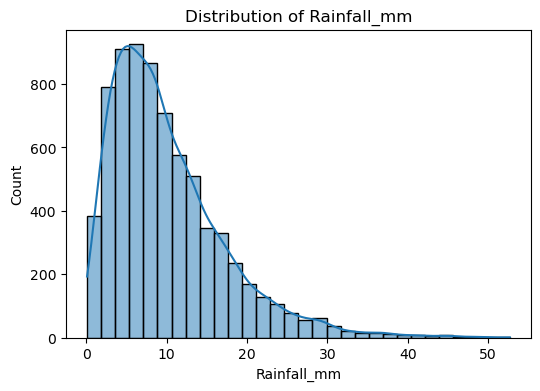

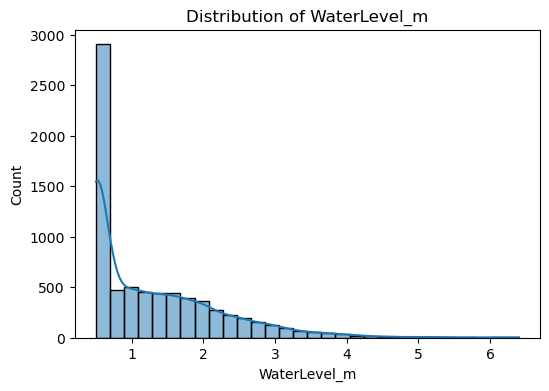

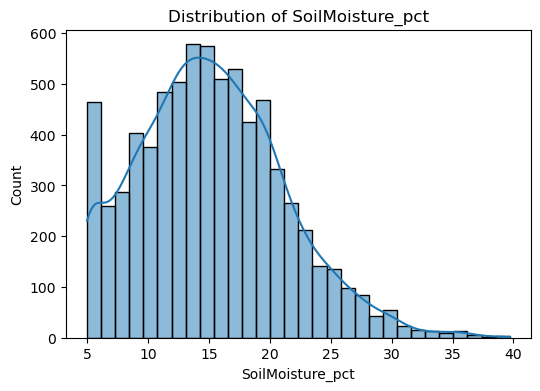

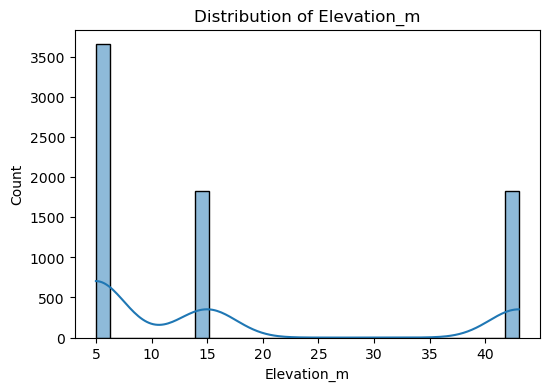

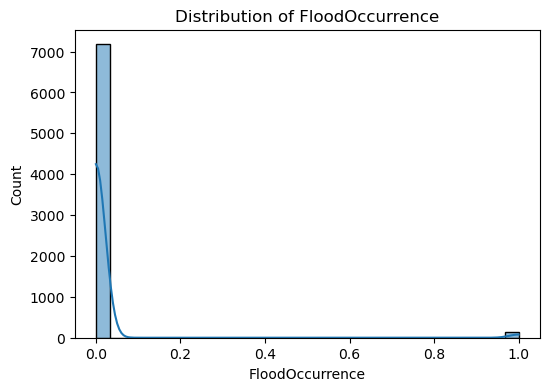

In [34]:
print("\nHistograms of numeric features:")
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(Flood[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 3. Correlation matrix

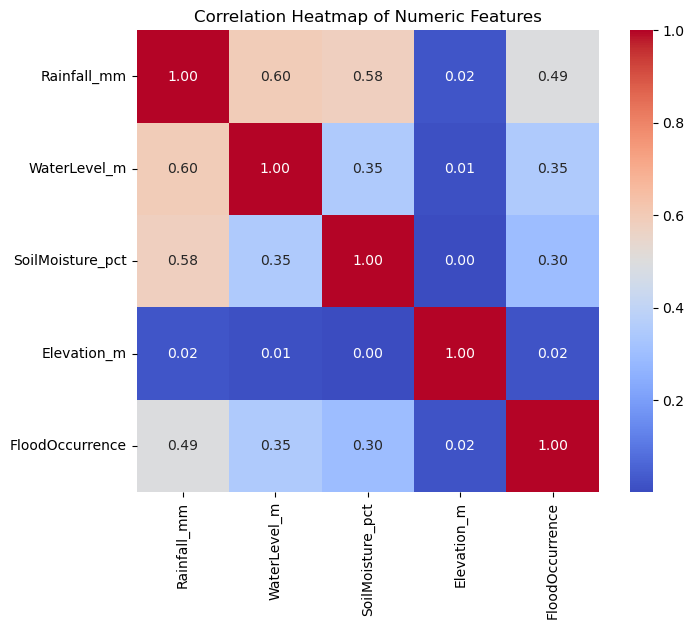

In [35]:
# Compute correlation matrix
corr = Flood[numeric_cols].corr()

# Plot heatmap

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## 4. Baseline models (default settings)

Features: `Rainfall_mm`, `WaterLevel_m`, `SoilMoisture_pct`, `Elevation_m`. Target: `FloodOccurrence`.

80/20 random split (`random_state=42`, not stratified). Features are scaled with `StandardScaler`, fit on the training set only.

In [22]:
# Define features and target for prediction
features = ['Rainfall_mm', 'WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m']
target = 'FloodOccurrence'

In [23]:
# define your dataset and split it into training and testing sets
from sklearn.model_selection import train_test_split

# Splitting data into train and test sets
X = Flood[features]
y = Flood[target]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Now apply StandardScaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [26]:
models = {
    'LogisticRegression': LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
}

In [27]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"{name} model with accuracy: {score}")

LogisticRegression model with accuracy: 0.9993160054719562
GaussianNB model with accuracy: 0.9808481532147743
SVC model with accuracy: 0.9986320109439124
KNeighborsClassifier model with accuracy: 0.9979480164158687
DecisionTreeClassifier model with accuracy: 1.0
RandomForestClassifier model with accuracy: 1.0


**Reading these scores:** accuracy is misleading here. Predicting "no flood" for every record would already score about 98.2%. That is why the final evaluation in notebook 02 uses precision, recall, F1 and ROC-AUC.

### Logistic Regression in detail

In [28]:
# Import Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train (fit) the model
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: Display model coefficients (feature importance)
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coefficients)

Accuracy: 0.9993160054719562

Confusion Matrix:
 [[1443    0]
 [   1   18]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1443
           1       1.00      0.95      0.97        19

    accuracy                           1.00      1462
   macro avg       1.00      0.97      0.99      1462
weighted avg       1.00      1.00      1.00      1462


Feature Importance:
             Feature  Coefficient
0       Rainfall_mm     5.743370
2  SoilMoisture_pct     0.442457
1      WaterLevel_m     0.213881
3       Elevation_m     0.028949
